In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [2]:
df = pd.read_csv("dataset/earthquake_data.csv")
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN


In [5]:
time_cols = [c for c in df.columns if 'time' in c or 'date' in c]
print("Time-like columns:", time_cols)

Time-like columns: ['date_time']


In [7]:
if time_cols:
    df['event_time'] = pd.to_datetime(
        df[time_cols[0]],
        errors='coerce',
        dayfirst=True
    )
else:
    df['event_time'] = pd.NaT


In [9]:
for col in ['latitude', 'lat']:
    if col in df.columns and 'latitude' not in df.columns:
        df.rename(columns={col: 'latitude'}, inplace=True)

In [11]:
for col in ['longitude', 'lon', 'long']:
    if col in df.columns and 'longitude' not in df.columns:
        df.rename(columns={col: 'longitude'}, inplace=True)

In [13]:
if 'mag' in df.columns and 'magnitude' not in df.columns:
    df.rename(columns={'mag': 'magnitude'}, inplace=True)

In [15]:
if df['event_time'].notna().any():
    df['year'] = df['event_time'].dt.year
    df['month'] = df['event_time'].dt.month
    df['day'] = df['event_time'].dt.day
    df['hour'] = df['event_time'].dt.hour
else:
    df['year'] = df['month'] = df['day'] = df['hour'] = np.nan


In [17]:
if 'depth' in df.columns:
    df['shallow'] = (df['depth'] < 70).astype(int)

In [19]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

In [21]:
if 'magnitude' not in numeric_cols:
    raise ValueError("Magnitude not found in numeric columns.")

In [23]:
X = df[numeric_cols].drop("magnitude", axis=1)
y = df["magnitude"]

In [25]:
X = X.fillna(X.mean())

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [29]:
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [31]:
preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

In [33]:
print("MODEL RESULTS:")
print("MSE:", mse)
print("R²:", r2)

MODEL RESULTS:
MSE: 0.03854287988676514
R²: 0.7208217906762051


In [35]:
import matplotlib.pyplot as plt
import numpy as np

In [37]:
importances = model.feature_importances_
feature_names = X.columns

In [39]:
indices = np.argsort(importances)

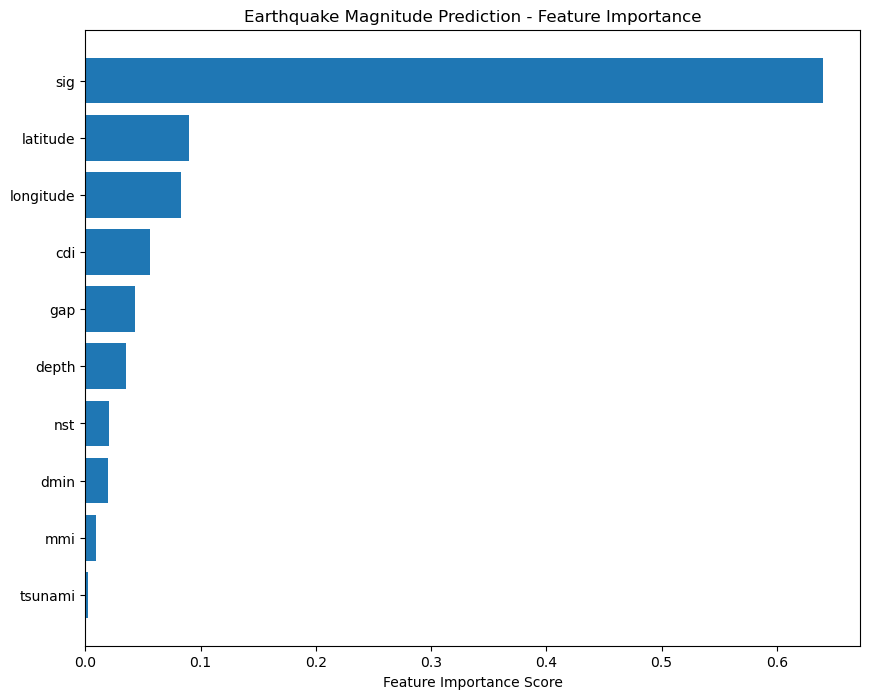

In [41]:
plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance Score")
plt.title("Earthquake Magnitude Prediction - Feature Importance")
plt.show()

In [45]:
from sklearn.preprocessing import StandardScaler

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [47]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv("dataset/earthquake_data.csv")

# Example columns (change as per your dataset)
X = df[["latitude", "longitude", "depth", "magnitude"]]
y = df["risk"]   # 0 = low, 1 = high

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Train XGBoost
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss"
)

model.fit(X_train_scaled, y_train)


joblib.dump(scaler, "models/earthquake_scaler.pkl")

print("Earthquake model saved ✅")


KeyError: 'risk'

In [51]:
# ================================
# EARTHQUAKE IMPACT (SIG) PREDICTION
# Input: lat, long, depth, magnitude
# Output: sig (impact score)
# ================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import joblib
import os

# 🔹 LOAD DATA
df = pd.read_csv("dataset/earthquake_data.csv")

print("Columns:", df.columns)
print(df.head())

# 🔹 FEATURES & TARGET
X = df[["latitude", "longitude", "depth", "magnitude"]]
y = df["sig"]

# 🔹 SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 SCALE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 MODEL
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# 🔹 EVALUATE
y_pred = model.predict(X_test_scaled)

print("\nModel Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# 🔹 SAVE MODEL
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/earthquake.pkl")
joblib.dump(scaler, "models/earthquake_scaler.pkl")

print("\n✅ Model & Scaler saved")

# ================================
# 🔥 PREDICTION FUNCTION
# ================================

def predict_earthquake_sig(sample_input):
    df_sample = pd.DataFrame([sample_input])

    # enforce column order
    df_sample = df_sample[["latitude", "longitude", "depth", "magnitude"]]

    scaled = scaler.transform(df_sample)

    # Ensemble predictions for confidence
    preds = np.array([tree.predict(scaled)[0] for tree in model.estimators_])

    predicted_sig = preds.mean()
    std_dev = preds.std()

    # 🔹 Confidence
    confidence = max(0, 1 - (std_dev / 200))  # scaled for sig range

    # 🔹 Probability (normalize sig)
    probability = min(predicted_sig / 1000, 1)

    # 🔹 Risk classification (based on sig)
    if predicted_sig < 100:
        risk = "Low"
    elif predicted_sig < 500:
        risk = "Medium"
    else:
        risk = "High"

    return {
        "predicted_sig": round(float(predicted_sig), 2),
        "probability": round(float(probability), 2),
        "confidence": round(float(confidence), 2),
        "risk": risk
    }

# ================================
# 🧪 TEST INPUT
# ================================

sample = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "depth": 12,
    "magnitude": 5.5
}

result = predict_earthquake_sig(sample)

print("\nPrediction Output:")
print(result)

Columns: Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')
                                          title  magnitude         date_time  \
0  M 7.0 - 18 km SW of Malango, Solomon Islands        7.0  22-11-2022 02:03   
1      M 6.9 - 204 km SW of Bengkulu, Indonesia        6.9  18-11-2022 13:37   
2                                      M 7.0 -         7.0  12-11-2022 07:09   
3           M 7.3 - 205 km ESE of Neiafu, Tonga        7.3  11-11-2022 10:48   
4                                      M 6.6 -         6.6  09-11-2022 10:14   

   cdi  mmi  alert  tsunami  sig net  nst   dmin   gap magType    depth  \
0    8    7  green        1  768  us  117  0.509  17.0     mww   14.000   
1    4    4  green        0  735  us   99  2.229  34.0     mww   25.000   
2    3    3  green        1  755  us  147  3.125  18.0 